## Dataset and Architecture Decision

For Sprint 2, the project uses the **Plastic - Paper - Garbage Bag Synthetic Images** dataset from Kaggle.

The dataset contains three image classes:

- **Plastic**
- **Paper**
- **Garbage Bag**

Because the input data consists of images, a **Convolutional Neural Network (CNN)** is more appropriate than a standard dense neural network. CNNs are designed to capture spatial patterns in images, such as edges, textures, shapes, and object features.

### Model Architecture

The planned CNN architecture is:

```text
Input Image
    ↓
Conv2D (32 filters, 3×3, ReLU)
    ↓
MaxPooling2D
    ↓
Conv2D (64 filters, 3×3, ReLU)
    ↓
MaxPooling2D
    ↓
Flatten
    ↓
Dense (128, ReLU)
    ↓
Dropout (0.3)
    ↓
Dense (3, Softmax)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive
import os

In [12]:

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:

print(os.listdir('/content/drive/MyDrive/PC/Bag Classes'))

['Garbage Bag Images', 'Paper Bag Images', 'Plastic Bag Images']


In [14]:
dataset_path = '/content/drive/MyDrive/PC/Bag Classes'

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)
        print(f"{folder}: {len(images)} images")

Garbage Bag Images: 5000 images
Paper Bag Images: 5000 images
Plastic Bag Images: 5000 images


Found 15000 files belonging to 3 classes.


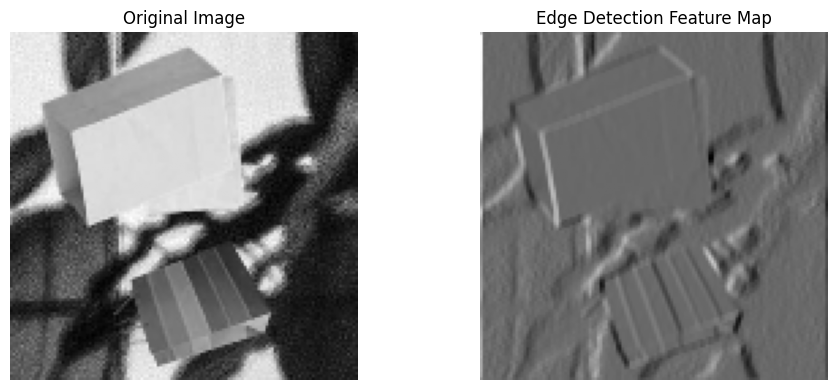

In [15]:
# Load one sample image
sample_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(128, 128),
    batch_size=1,
    shuffle=True,
    seed=42
)

# Get one image
image, label = next(iter(sample_ds))

# Convert to NumPy and grayscale
image = image[0].numpy()

gray_image = np.mean(image, axis=2)

# Hand-defined vertical edge detection filter
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

# Add zero padding
padded = np.pad(gray_image, pad_width=1, mode='constant')

# Create feature map
feature_map = np.zeros_like(gray_image)

# Convolution
for i in range(gray_image.shape[0]):
    for j in range(gray_image.shape[1]):
        patch = padded[i:i+3, j:j+3]
        feature_map[i, j] = np.sum(patch * kernel)

# Visualize
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(feature_map, cmap='gray')
plt.title('Edge Detection Feature Map')
plt.axis('off')

plt.tight_layout()
plt.show()

### Edge Detection Feature Map

A hand-defined `3 × 3` convolution filter was applied to a sample image to detect vertical edges.

The left image shows the original grayscale image, while the right image shows the resulting feature map. Stronger regions in the feature map correspond to areas with significant changes in pixel intensity, highlighting vertical edges and object boundaries.

This simple experiment demonstrates the basic principle of convolution used in CNNs. In a real CNN, these filters are learned automatically during training rather than manually defined.

### Parameter Sharing in CNNs

A CNN uses the **same filter across the entire image**, so the filter's weights are reused at every location.

For example, a `3 × 3` filter applied to an RGB image has:

$$
3 \times 3 \times 3 + 1 = 28
$$

learnable parameters, including the bias.

The same 28 weights are reused as the filter moves across the whole image. Therefore, the number of parameters does **not** increase with the image size.

In contrast, a dense layer connects **every input pixel to every neuron**. For a `200 × 200 × 3` image and only 64 neurons:

$$
200 \times 200 \times 3 \times 64 + 64
= 7{,}680{,}064
$$

parameters are required in the first layer alone.

Therefore, CNNs need far fewer weights because of **parameter sharing** and **local connectivity**. The same learned filter can detect the same pattern, such as an edge or texture, anywhere in the image.